# EDA der Labels

In [1]:
# import librarys
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# check if current directory is "main" for correct path handling
current_dir = os.path.basename(os.getcwd())

if current_dir != "main":
    os.chdir("..")

Im ersten Schritt wird ein Dataframe aus der Excel Tabelle erstellt mit den wichtigen Spalten.

In [ ]:
# read df with needed columns
df = pd.read_excel(
    "data/labels/Libary_Bruchbilder.xlsx", 
    usecols="A, B, D:I"  
)
df

,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate
0,Image_00001,1,B,Sikaflex-668,SCP,SA-100,SP-507,Glas
1,Image_00002,1,C,Sikaflex-668,SCP,SA-100,SP-507,Glas
2,Image_00003,1,F,Sikaflex-668,SCP,SA-100,SP-507,Glas
3,Image_00004,1,G,Sikaflex-668,SCP,SA-100,SP-507,Glas
4,Image_00005,1,L,Sikaflex-668,SCP,SA-100,SP-507,Glas
...,...,...,...,...,...,...,...,...
1003,Image_01004,1,B,Sikaflex-554 PC,NaN,SA-205,NaN,GFK
1004,Image_01005,1,C,Sikaflex-554 PC,NaN,SA-205,NaN,GFK
1005,Image_01006,2 SF 15%,F,Sikaflex-554 PC,NaN,SA-205,NaN,GFK
1006,Image_01007,1,G,Sikaflex-554 PC,NaN,SA-205,NaN,GFK


In [32]:
df_train = pd.read_excel(
    "data/train/labels/train_val.xlsx",
    usecols="A, B, D:I"
)
df_train

,Image No.,Rating,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path
0,Image_00009,1,Sikaflex-668 PC,SCP,SA-100,SP-507,Glas,Image_FHNW_00009.jpg
1,Image_00156,1,Sikaflex-254,AP-C,SA-100,SP-207,Grundierung,Image_FHNW_00156.jpg
2,Image_00434,2 SCPrF 10%,Sikaflex-271 PC,AP-C,NaN,SP-207,Alu Guss,Image_FHNW_00434.jpg
3,Image_00462,1,Sikaflex-271 PC,AP-C,NaN,SP-207,Alu roh,Image_FHNW_00462.jpg
4,Image_00567,1,Sikaflex-668,SCP,SA-100,NaN,Pulverlack,Image_FHNW_00567.jpg
...,...,...,...,...,...,...,...,...
775,Image_00419,1,Sikaflex-252,SCP,NaN,SP-207,Paint,Image_FHNW_00419.jpg
776,Image_00559,2 ES 20%,Sikaflex-268,SCP,SA-100,NaN,Pulverlack,Image_FHNW_00559.jpg
777,Image_00636,1,Sikaflex-268,SCP,NaN,SP-207,Pulverlack,Image_FHNW_00636.jpg
778,Image_00458,1,Sikaflex-271 PC,AP-C,NaN,SP-207,Alu roh,Image_FHNW_00458.jpg


In [33]:
df_test = pd.read_excel(
    "data/test/labels/test.xlsx",
    usecols="A, B, D:I"
)
df_test

,Image No.,Rating,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path
0,Image_00414,1 PaDF <5%,Sikaflex-271 PC,SCP,NaN,SP-207,Paint,Image_FHNW_00414.jpg
1,Image_00757,1,Sikaflex-268 PC,AP-C,NaN,SP-207,GFK,Image_FHNW_00757.jpg
2,Image_00921,1,Sikaflex-668,SCP,NaN,NaN,Decklack,Image_FHNW_00921.jpg
3,Image_00664,1,Sikaflex-522,SCP,Plasma 1,NaN,PS,Image_FHNW_00664.jpg
4,Image_00374,2 PaIF 5%,SikaTack-Go!,Benzin,SA-306 LUM,NaN,Pulverlack,Image_FHNW_00374.jpg
...,...,...,...,...,...,...,...,...
190,Image_00429,1,Sikaflex-252,SCP,NaN,SP-507,Paint,Image_FHNW_00429.jpg
191,Image_00519,5,Sikaflex-668 PC,SCP,Plasma 1,NaN,PP,Image_FHNW_00519.jpg
192,Image_00663,3 SF 50%,Sikaflex-522,SCP,Plasma 1,NaN,PS,Image_FHNW_00663.jpg
193,Image_00933,5,Sikaflex-268,SCP,SA-307,NaN,Decklack,Image_FHNW_00933.jpg


Hier zählen wir die einzelnen Substrate um diese plotten zu können.

In [4]:
# count sum of df["Substrate"].unique()
substrate_counts = df["Substrate"].value_counts()
substrate_counts

Substrate
Pulverlack     221
Alu            135
GFK            117
Grundierung     79
Glas            78
Decklack        70
PS              56
PVC             53
Paint           33
PET             32
PP              24
Alu Guss        23
Alu roh         22
HPL             20
2K-PUR-Lack     20
Edelstahl       10
Keramik         10
Sarnafil         5
Name: count, dtype: int64

## Verteilung der Substrate

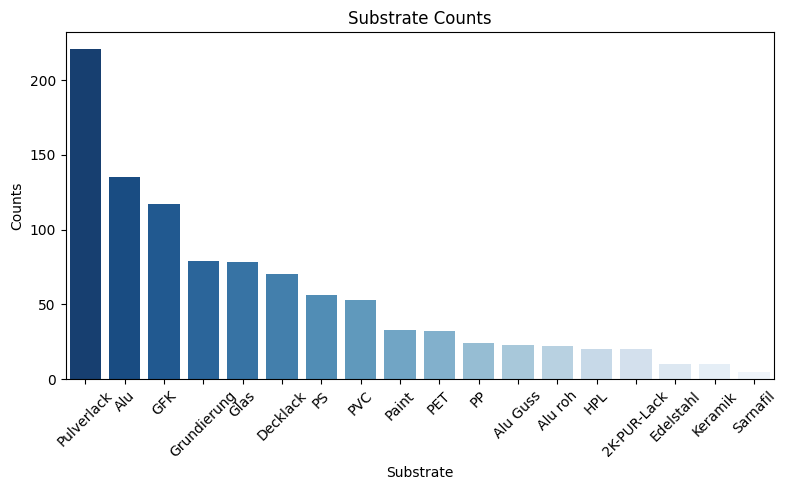

In [5]:
# plot substrate_counts
plt.figure(figsize=(8, 5))
sns.barplot(x=substrate_counts.index, 
            y=substrate_counts.values,
            palette = "Blues_r")
plt.title("Substrate Counts")
plt.xlabel("Substrate")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bei den Substraten herscht eine grosse Unausgewogenheit. So ist Pulverlack über 200 mal verwendet worden, sohingegen Sarnafil nur fünf mal zum Einsatz kam. Für das Modelltraining sollten diese Erkenntnisse allerdings keinen Einfluss haben.

Mit df.describe() wird eine statistische Übersicht über die numerischen Spalten erstellt. 

In [6]:
df.describe()

,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate
count,1008,1008,1008,1008,958,596,501,1008
unique,1008,49,6,18,6,6,4,18
top,Image_00001,1,F,Sikaflex-268,SCP,SA-100,SP-207,Pulverlack
freq,1,709,193,163,635,287,329,221


In der Tabelle ist zu erkennen, dass es 1008 Bilder und 1008 Ratings gibt. Dies entspricht genau einem Rating pro Bild. Wichtig zu sehen ist auch, dass 1008 Substrate verwendet wurden, aber nur 953 Pre-treatement 1, 596 Pre-treatment 2 und 501 Pre-treatment 3 gemacht wurden. 

## Untersuchen der Ratings

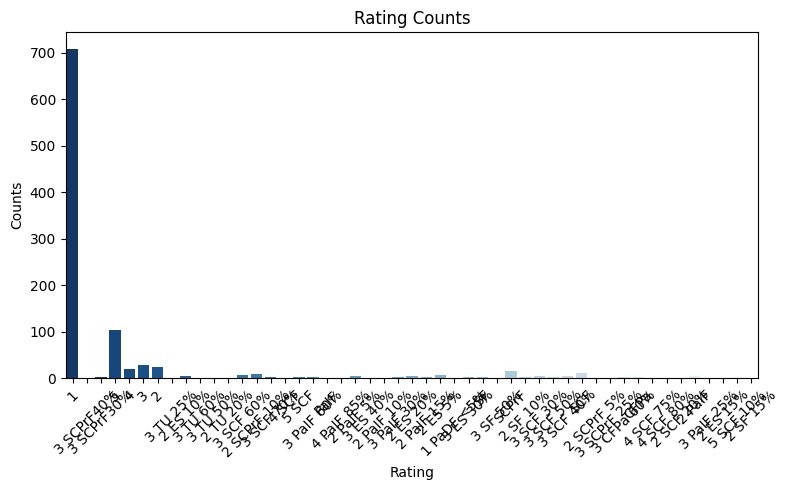

In [7]:
# plot Rating counts
plt.figure(figsize=(8, 5))
sns.countplot(x="Rating", hue="Rating", data=df, palette="Blues_r", legend=False)
plt.title("Rating Counts")
plt.xlabel("Rating")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In dem Plot sehen wir, dass wir viele verschiedene Ratings haben. Dies bedeutet, dass wir die Daten bereinigen müssen, damit alle Ratings als Integer wiedergegeben werden. Dies gelingt uns in dem wir eine Spalte "Ratings_cleaned" hinzufügen, wo jeweils die Ratings als Integer extrahiert wurden. 

In [34]:
# clean ratings by extracting the first digit

df['Ratings_cleaned'] = df['Rating'].astype(str).str.extract(r'(\d)').astype(float)
df_train['Ratings_cleaned'] = df_train['Rating'].astype(str).str.extract(r'(\d)').astype(float)
df_test['Ratings_cleaned'] = df_test['Rating'].astype(str).str.extract(r'(\d)').astype(float)
df.tail(20)

,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Ratings_cleaned
988,Image_00989,2,F,Sikaflex-552 AT,AP-C,SA-205,NaN,GFK,2.0
989,Image_00990,2,G,Sikaflex-552 AT,AP-C,SA-205,NaN,GFK,2.0
990,Image_00991,5,L,Sikaflex-552 AT,AP-C,SA-205,NaN,GFK,5.0
991,Image_00992,2,A,Sikaflex-554 PC,AP-C,SA-205,NaN,GFK,2.0
992,Image_00993,1,B,Sikaflex-554 PC,AP-C,SA-205,NaN,GFK,1.0
993,Image_00994,1,C,Sikaflex-554 PC,AP-C,SA-205,NaN,GFK,1.0
994,Image_00995,1,F,Sikaflex-554 PC,AP-C,SA-205,NaN,GFK,1.0
995,Image_00996,1,G,Sikaflex-554 PC,AP-C,SA-205,NaN,GFK,1.0
996,Image_00997,5,L,Sikaflex-554 PC,AP-C,SA-205,NaN,GFK,5.0
997,Image_00998,1,B,Sikaflex-521 UV,NaN,SA-205,NaN,GFK,1.0


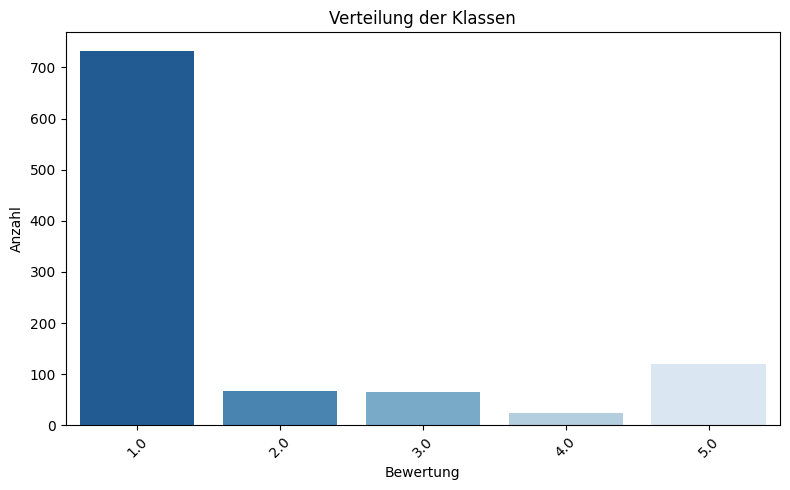

In [ ]:
# plot rating counts
# plot rating counts
plt.figure(figsize=(8, 5))
sns.countplot(x="Ratings_cleaned",  data=df, legend=False, palette="Blues_r")
plt.title("Verteilung der Klassen")
plt.xlabel("Bewertung")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In dem Barchart ist ersichtlich, dass ein grosser Teil der Labels mit 1 gekennzeichnet ist. Die Klassen der Klebstoffe ist also sehr stark unausgeglichen. Dies kann zu schlechteren Ergebnissen bei den Modellen führen, da sich ein Modell beim Training zu stark auf Klasse 1 fokusieren kann und somit diese Klasse am häufigsten vorhersagt. 

Anhand der unasgeglichenen haben wir uns entschieden bei der Evaluation der Deep Learning Modelle zu versuchen einen möglichst hohen Macro F1-Score zu erhalten. Der Macro F1-Score berechnet sich aus dem arithmetische Mittelwert aller klassenspezifischen F1-Werte. Diese Metrik macht bei einem unausgewogenen Datensatz durchaus Sinn. 

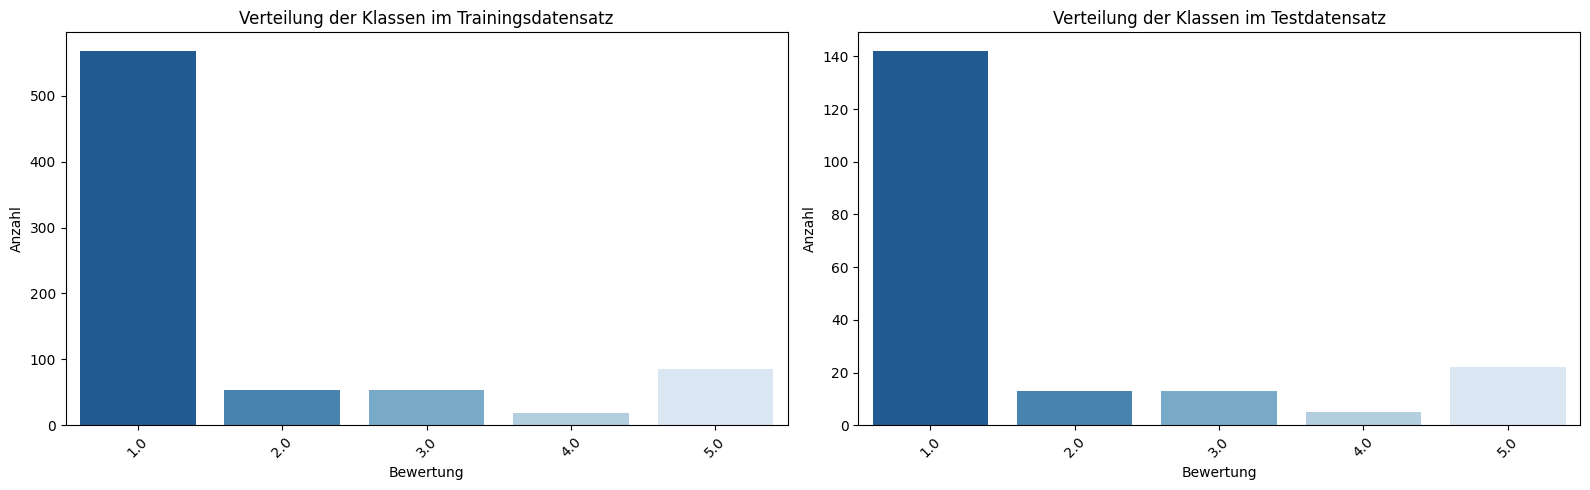

In [41]:
# plot rating counts for df_train and df_test next to each other
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.countplot(x="Ratings_cleaned",  data=df_train, legend=False, palette="Blues_r")
plt.title("Verteilung der Klassen im Trainingsdatensatz")
plt.xlabel("Bewertung")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x="Ratings_cleaned",  data=df_test, legend=False, palette="Blues_r")
plt.title("Verteilung der Klassen im Testdatensatz")
plt.xlabel("Bewertung")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bei dem Testdatensatz und Traindatensatz sieht die Verteilung gleich aus. Dies schliesst darauf, dass der Train-Test-Split korrekt gemacht wurde. 

In [10]:
# how many nan values are in the df
nan_counts = df.isna().sum()
nan_counts

Image No.            0
Rating               0
Cond.                0
Product              0
Pre-treatment 1     50
Pre-treatment 2    412
Pre-treatment 3    507
Substrate            0
Ratings_cleaned     33
dtype: int64

Wir haben 33 NA Werte in der Spalte Ratings_cleaned. Dies bedeutet dass 33 Proben keiner Kategorie zugeordnet werden können. Wir wollen nun herausfinden bei welchen Proben dies der Fall ist um diesen Werten ein Rating hinzufügen zu können.

Die fehlenden Werte bei den drei Pre-treatements können vernachlässigt werden, da nicht immer ein Pre-treatment angewendet werden muss.

## NA Werte bei Rating

In [11]:
# show rows with nan values in column Ratings_cleaned
df_nan = df[df['Ratings_cleaned'].isna()]
df_nan


,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Ratings_cleaned
333,Image_00334,PaIF,F,SikaTack-Go!,Benzin,SA-306 LUM,NaN,Pulverlack,NaN
661,Image_00662,SF,F,Sikaflex-522,SCP,Plasma 1,NaN,PS,NaN
666,Image_00667,SF,F,Sikaflex-522,SCP,Plasma 1,NaN,PS,NaN
667,Image_00668,SF,G,Sikaflex-522,SCP,Plasma 1,NaN,PS,NaN
674,Image_00675,SCPrF,B,Sikaflex-522,SCP,NaN,SP-507,PS,NaN
675,Image_00676,SCPrF,C,Sikaflex-522,SCP,NaN,SP-507,PS,NaN
676,Image_00677,SCPrF,F,Sikaflex-522,SCP,NaN,SP-507,PS,NaN
677,Image_00678,SCPrF,G,Sikaflex-522,SCP,NaN,SP-507,PS,NaN
678,Image_00679,SCPrF,L,Sikaflex-522,SCP,NaN,SP-507,PS,NaN
679,Image_00680,SCPrF,L,Sikaflex-522,SCP,NaN,SP-507,PS,NaN


Nach Absprache mit dem Kunden (Gianluca De Fezza) wurde uns mitgeteilt, dass die fehlenden Ratings immer eine 1 sind, ausser bei den "SCF" diese sind mit einer 5 zu bewerten. Um die fehlenden Werte im Datensatz zu korrigieren, ersetzen wir die NA-Werte mit einem For-Loop. 

In [12]:
# add correct missing values to Ratings_cleaned
df['Ratings_cleaned'] = df.apply(
    lambda row: 5 if pd.isna(row['Ratings_cleaned']) and row['Rating'] == 'SCF'
    else (1 if pd.isna(row['Ratings_cleaned']) else row['Ratings_cleaned']),
    axis=1
)

print(df['Ratings_cleaned'].isna().sum())  # should be 0

0


Nachdem wir die fehlenden Werte in der Spalte “Ratings_cleaned” ersetzt haben, sind dort keine NA-Einträge mehr vorhanden. Dadurch stehen uns 33 zusätzliche Werte zur Verfügung, die vorher gefehlt haben. Das ist besonders wichtig, weil die Bewertungsklasse 5 ohnehin nur selten im Datensatz vorkommt. Eine ausgeglichenere Klassenverteilung im Trainings- und Testdatensatz kann zu einem besseren Modell führen.

### Häufigste Klebstoffe

Nun wollen wir noch prüfen, welcher Klebstoff wie oft getestet wurde.

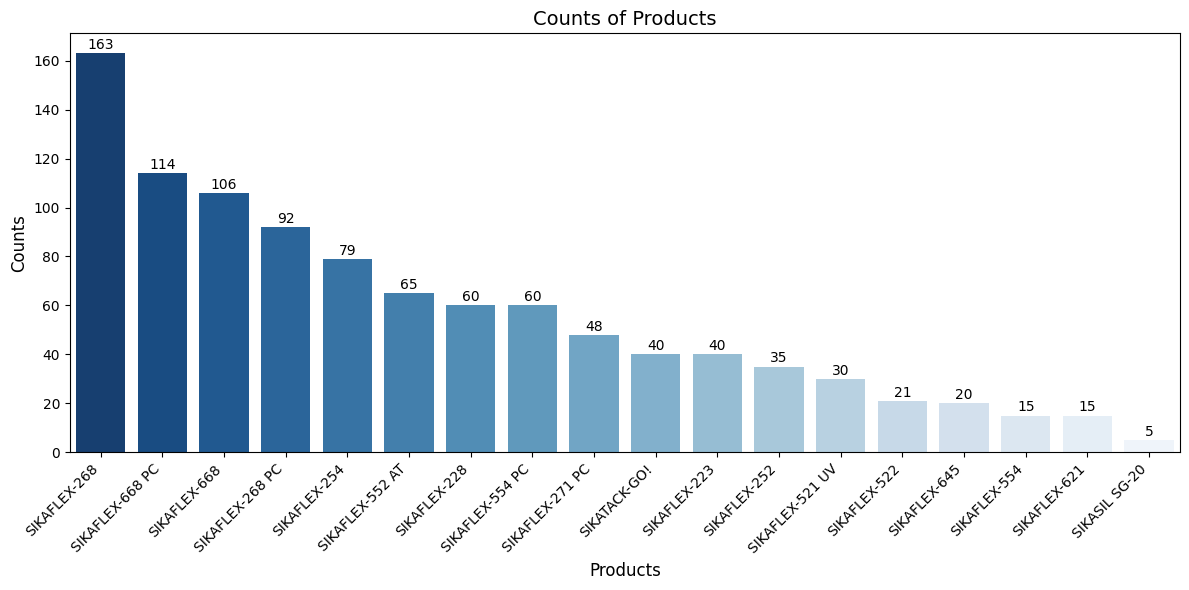

In [15]:
# Get sorted product order and corresponding colors
prod = df["Product"].astype(str).str.strip().str.upper()
prod_counts = prod.value_counts()
prod_order = prod_counts.index
num_items = len(prod_order)

# Create a color palette with the same number of colors as products
palette = sns.color_palette("Blues_r", n_colors=num_items)
palette_dict = dict(zip(prod_order, palette))

# plot product counts
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    x=prod,
    order=prod_order,
    hue=prod,
    palette=palette_dict,
    legend=False
)

# write counts on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,  # x-avg of the bar
            height + 0.5,                   # y: slightly above the bar
            f"{int(height)}",               # count as integer
            ha="center",                    # horizontal center
            va="bottom",                    # vertical bottom
            fontsize=10,
            color="black"
        )

# Set plot title and labels
plt.title("Counts of Products", fontsize=14)
plt.xlabel("Products", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In dieser Abbildung ist zu erkennen, dass der Sikaflex-268 mit Abstand am häufigsten verwendet wurde. Nur sehr wenige Daten liegen uns von dem Sikasil SG-20 vor. Dies kann dazu führen, dass die Modelle auf den Sikasil SG-20 weniger gut trainiert werden können und somit nicht ideale Vorhersagen treffen könnten.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Image No.        1008 non-null   object 
 1   Rating           1008 non-null   object 
 2   Cond.            1008 non-null   object 
 3   Product          1008 non-null   object 
 4   Pre-treatment 1  958 non-null    object 
 5   Pre-treatment 2  596 non-null    object 
 6   Pre-treatment 3  501 non-null    object 
 7   Substrate        1008 non-null   object 
 8   Ratings_cleaned  1008 non-null   float64
dtypes: float64(1), object(8)
memory usage: 71.0+ KB


In [17]:
df.head()

,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Ratings_cleaned
0,Image_00001,1,B,Sikaflex-668,SCP,SA-100,SP-507,Glas,1.0
1,Image_00002,1,C,Sikaflex-668,SCP,SA-100,SP-507,Glas,1.0
2,Image_00003,1,F,Sikaflex-668,SCP,SA-100,SP-507,Glas,1.0
3,Image_00004,1,G,Sikaflex-668,SCP,SA-100,SP-507,Glas,1.0
4,Image_00005,1,L,Sikaflex-668,SCP,SA-100,SP-507,Glas,1.0


# Analysieren der Daten im Trainset

Um sicherzustellen, dass es zu keiner Dataleakage kommt, also dass wir Entscheidungen anhand der Test Daten vornehmen würden und somit das Modell beinflussen könnten, werden die folgenden Analysen auf dem Trainset durchgeführt.

In [18]:
# load test data
df_train = pd.read_excel(
    "data/train/labels/train_val.xlsx", 
    usecols="A, B, D:I"  
)
df_train.head()

,Image No.,Rating,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path
0,Image_00009,1,Sikaflex-668 PC,SCP,SA-100,SP-507,Glas,Image_FHNW_00009.jpg
1,Image_00156,1,Sikaflex-254,AP-C,SA-100,SP-207,Grundierung,Image_FHNW_00156.jpg
2,Image_00434,2 SCPrF 10%,Sikaflex-271 PC,AP-C,NaN,SP-207,Alu Guss,Image_FHNW_00434.jpg
3,Image_00462,1,Sikaflex-271 PC,AP-C,NaN,SP-207,Alu roh,Image_FHNW_00462.jpg
4,Image_00567,1,Sikaflex-668,SCP,SA-100,NaN,Pulverlack,Image_FHNW_00567.jpg


In [19]:
df_train.describe()


,Image No.,Rating,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path
count,780,780,780,741,467,388,780,780
unique,780,42,18,6,6,4,18,780
top,Image_00009,1,Sikaflex-268,SCP,SA-100,SP-207,Pulverlack,Image_FHNW_00009.jpg
freq,1,568,132,484,228,269,176,1


Ebenfalls werden zuerst wieder die Labels angepasst, dass man nurnoch die Labels 1-5 hat. 

In [20]:
df_train['Ratings_cleaned'] = df_train['Rating'].astype(str).str.extract(r'(\d)').astype(float)


In [21]:
# test if there are any NaN values in Ratings_cleaned
df_train.Ratings_cleaned.isna().sum()

np.int64(0)

### Average Rating pro Produkt und Substrat
Hierbei wird geprüft, welche Produkte und welche Substrate einen guten oder schlechten Durchschnittsscoore haben.

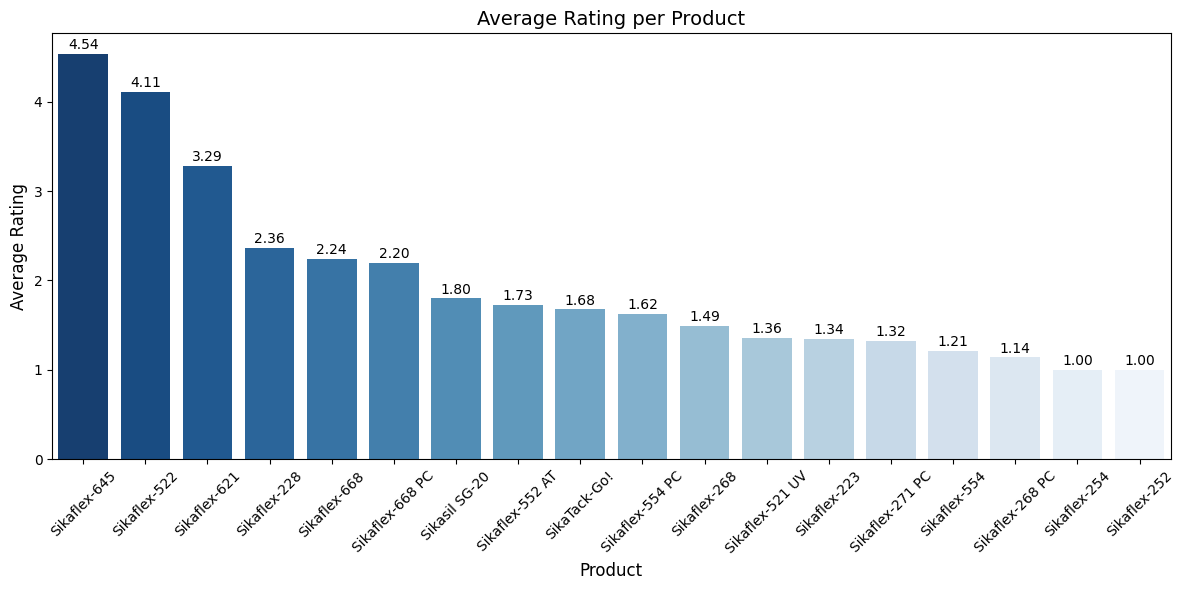

In [22]:
# what is the average rating per product
avg_rating_per_product = df_train.groupby("Product")["Ratings_cleaned"].mean().sort_values(ascending=False)

# plot average rating per product
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=avg_rating_per_product.index,
    y=avg_rating_per_product.values,
    palette="Blues_r"
)

# add values on top of bars
for i, v in enumerate(avg_rating_per_product.values):
    ax.text(
        i,                      # x-Position: bar index
        v + 0.02,               # y-Position: slightly above the bar
        f"{v:.2f}",             # Text: value with 2 decimal places
        ha="center",            # horizontal alignment: center
        va="bottom",            # vertical alignment: bottom (above the bar)
        fontsize=10,
        color="black"
                )

# add title and labels
plt.title("Average Rating per Product", fontsize=14)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In dieser Grafik sieht man, dass es zwei Produkte gibt (Sikaflex-252 & Sikaflex-254) welche einen Durchschnitt von 1 haben, was bedeutet, dass diese beiden Klebstoffe immer in die beste Klasse eingeteilt wurden. Der Klebstof Sikaflex-645 hingegen ist im Datensatz am schlechtesten und hat ein Durschnittsrating von 4.54. 

Weiter unten wird noch eine Heatmap geplottet, welche den Zusammenhang von Produkt und Substrat auf das Rating anzeigen.

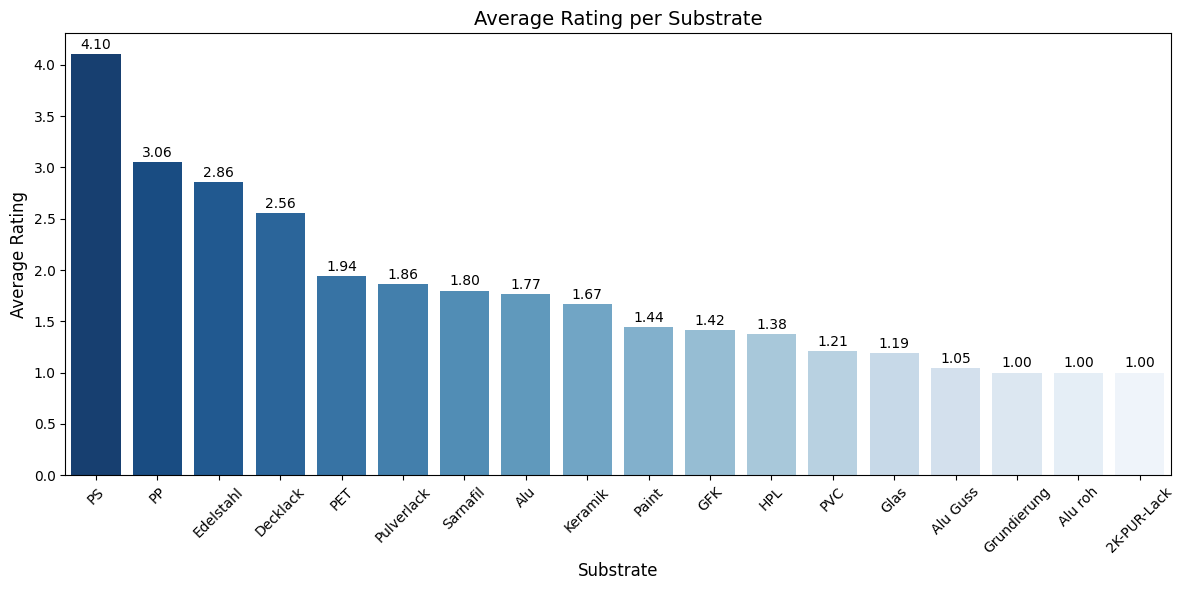

In [23]:
# what is the average rating per substrate
avg_rating_per_substrate = df_train.groupby("Substrate")["Ratings_cleaned"].mean().sort_values(ascending=False)

# create a bar plot for average rating per substrate
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=avg_rating_per_substrate.index,
    y=avg_rating_per_substrate.values,
    palette="Blues_r"
)

# add values on top of bars
for i, v in enumerate(avg_rating_per_substrate.values):
    ax.text(
        i,                      # x-Position: bar index
        v + 0.02,               # y-Position: slightly above the bar
        f"{v:.2f}",             # Text: value with 2 decimal places
        ha="center",            # horizontal alignment: center
        va="bottom",            # vertical alignment: bottom (above the bar)
        fontsize=10,
        color="black"
    )

# add title and labels
plt.title("Average Rating per Substrate", fontsize=14)
plt.xlabel("Substrate", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In dem Balkendiagramm ist zu erkennen welche Substrate einen hohen oder tiefen Durchschnittsscore bei den Labels haben. Das Substrat mit den schlechtesten Durschnittsratings ist das Substrat **PS**. Die Substrate **Grundierung**, **Alu roh** und **2K-PUR-Lack** haben einen Durchschnitt von 1, was bedeutet, dass die Klebstoffe auf diesen Substraten immer sehr gut hafteten. 

### Heatmap Product vs Substrate

Mit einer Heatmap wollen wir nun untersuchen, ob es bestimmte Muster oder Auffälligkeiten gibt, welcher Klebstoff auf welchem Substrat besonders gut oder schlecht haftet. 

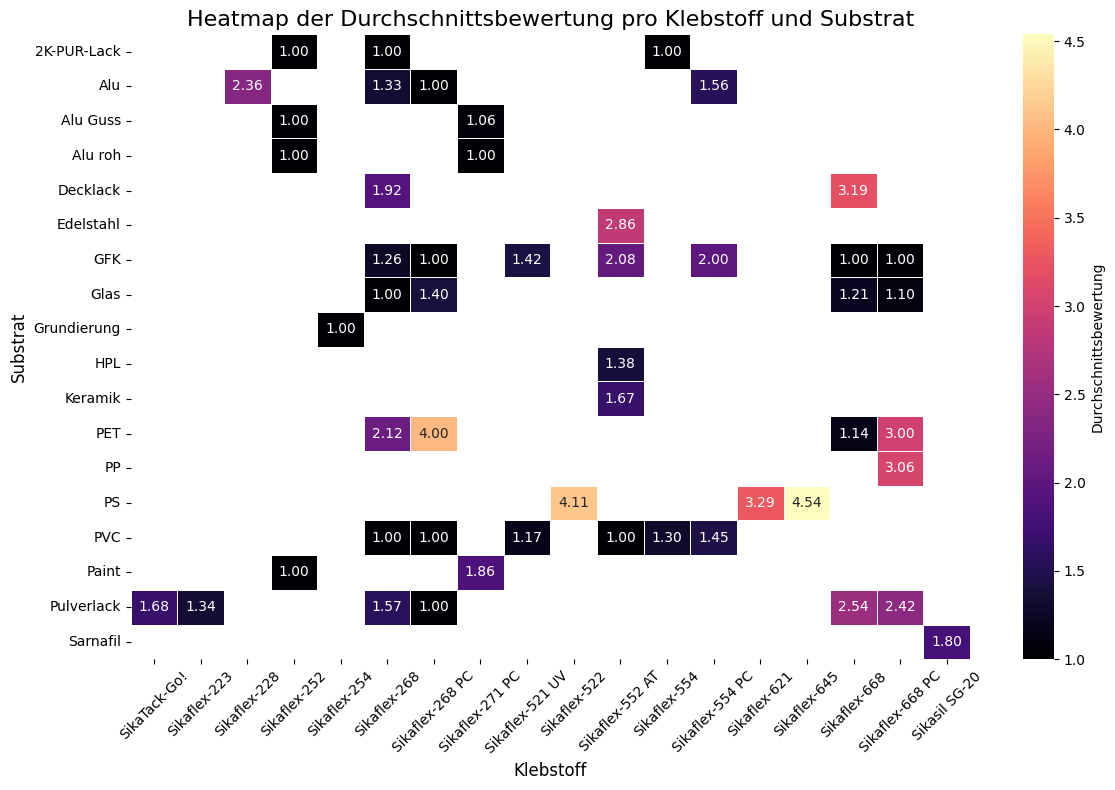

In [26]:
# heatmap with product on x and substrate on y for average rating
heatmap_data = df_train.pivot_table(
    index="Substrate", 
    columns="Product", 
    values="Ratings_cleaned", 
    aggfunc="mean"
)
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    cbar_kws={"label": "Durchschnittsbewertung"},
    linewidths=0.5
)
plt.title("Heatmap der Durchschnittsbewertung pro Klebstoff und Substrat", fontsize=16)
plt.xlabel("Klebstoff", fontsize=12)
plt.ylabel("Substrat", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In der Average Rating Heatmap per Product and Substrate ist zu erkennen, welches Silikat auf welcher Unterlage besonders gut oder schlecht haftet. Auffällig ist das Substrag PS, welches in der besten Kombination ein Durchschnittsrating von 3.29 erreicht hat. Für dieses Substrat ist also keiner der getesteten Klebstoffe geeignet. 

Es ist interessant zu sehen, dass der Klebstof Sikaflex-645 nur auf dem Substrat "PS" gestestet wurde, was dazu geführt hat, dass der Klebstoff das schlechteste Durchschnittsrating erhalten hat. 

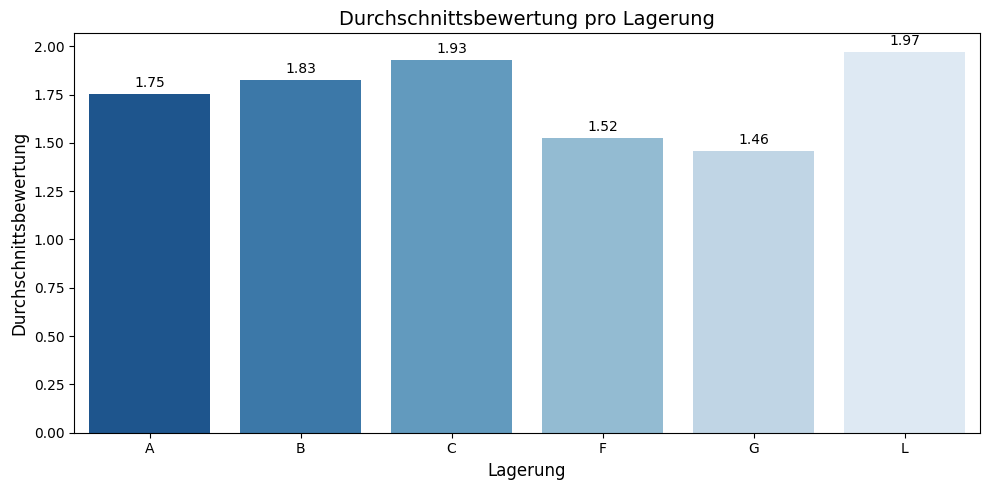

In [28]:
# plot barplot for average rating for all conditions in df["Cond."]

avg_rating_per_cond = df.groupby("Cond.")["Ratings_cleaned"].mean().sort_index()
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=avg_rating_per_cond.index,
    y=avg_rating_per_cond.values,
    palette="Blues_r"
)
# add values on top of bars
for i, v in enumerate(avg_rating_per_cond.values):
    ax.text(
        i,                      # x-Position: bar index
        v + 0.02,               # y-Position: slightly above the bar
        f"{v:.2f}",             # Text: value with 2 decimal places
        ha="center",            # horizontal alignment: center
        va="bottom",            # vertical alignment: bottom (above the bar)
        fontsize=10,
        color="black"
    )
# add title and labels
plt.title("Durchschnittsbewertung pro Lagerung", fontsize=14)
plt.xlabel("Lagerung", fontsize=12)
plt.ylabel("Durchschnittsbewertung", fontsize=12)                   
plt.tight_layout()
plt.show()

In dieser Grafik ist interessant zu beobachten, dass nicht A oder B das tiefste average Rating haben, sondern die Conditions G und F, obwohl diesen in den Tests nach den Conditions A, B und C durchgeführt werden. Dies kann daran liegen, dass die Vorgänge im Backofen (F) und Abkühlen (G) die Klebstoffe wieder verbessert.

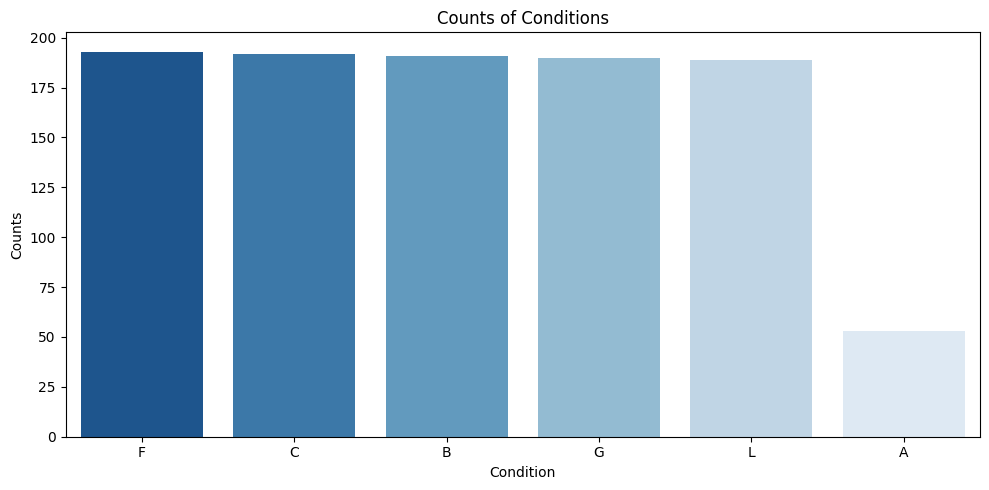

In [ ]:
# what Cond. is most common
cond_counts = df["Cond."].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(
    x=cond_counts.index,
    y=cond_counts.values,
    palette="Blues_r"
)
plt.title("Counts of Conditions")
plt.xlabel("Condition")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

Als letzes untersuchten wir, welche Condition am häufigsten vorkommt. Glücklicherweise sind alle Conditions (ausser A) gleichhäufig vertreten. Dies bedeutet, dass mit allen Experimenten jeweils alle Conditions durchgemacht wurden. 

Die Condition A ist am seltensten vertreten, weil dieser Schritt bei den meisten Untersuchungen übersprungen wird. 